# Model
This is the full 3D model from Optimal (Un)Conventional Monetary Policy (Andrey Alexandrov and Markus K. Brunnermeier). 

It does not require a separate planner model.  Instead, it:

1. solves the static constrained-efficient FOCs pointwise in ``sig2`` ($\tilde{\sigma}^2$);
2. differentiates the resulting allocation with autograd;
3. recovers the implementing policy fields from the paper's equations; and
4. solves the seven-unknown 3D PDE/algebraic system.

The efficient-path long-bond price is the restriction of the 3D ``PL`` network to ``(sig2, eta_eff(sig2), u_eff)``.  
Its total derivatives therefore remain coupled to the 3D solution, and ``PL(sig2_ss, eta_eff_ss, u_eff) = 1`` fixes the nominal price normalization.
**Fix (perturbed / exogenous-policy solve).** With an exogenous policy table the four algebraic unknowns ($\sigma^\eta$, $\chi$, $\alpha$, $\nu$) used to be free point-networks fitted to the F1–F4 residual. That system has more than one root (paper, Fig. 4); once the efficient-path anchors are dropped, training slides the point-nets onto the wrong branch ($\sigma^\eta \approx 0.016$ instead of $0.0064$ at this calibration), which corrupts the drifts and moves the steady state (e.g. $u_{ss}=0.905$ at $C=1$). As in MATLAB's `inner_loop.m`, the algebraic block is now solved **exactly at every point by Newton, warm-started at the efficient root** (`compute_inner`), and only the three PDE fields ($\vartheta$, $P^L$, $\pi$) are trained. A $C=1$ check (no retraining) must reproduce the optimal-policy steady state and loadings before any $C\neq 1$ run.


In [1]:
import io
import contextlib
import os
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import torch

from deep_macrofin import (Comparator, LossReductionMethod, OptimizerType, PDEModel, set_seeds)


In [2]:
# Core parameter dictionary (planner real block + sticky-price / long-bond constants).
params = {
    # --- planner / real block ---
    "rho": 0.07,        # discount rate
    "a": 0.18,          # productivity
    "delta": 0.01,      # depreciation
    "phi": 5.0,         # investment adjustment
    "bs": 0.15,         # mean reversion of \tilde{sigma}^2
    "sig2_ss": 0.5,     # steady-state idiosyncratic risk
    "nus": 0.02,        # diffusion scale of \tilde{sigma}^2
    "varphi": 0.8,      # relative idiosyncratic loading
    "spp": 1.0,
    "lam_I": 0.18 * 0.001,   # type-switching intensity
    "sig2_min": 0.8,    # sig2 domain lower factor (times sig2_ss)
    "sig2_max": 1.2,    # sig2 domain upper factor (times sig2_ss)
    # --- sticky-price / long-bond block (needed for the 3D solve) ---
    "e": 10.0,          # demand elasticity (epsilon)
    "kappa": 100.0,     # Rotemberg adjustment cost
    "cnu": 0.1,         # transaction-cost level
    "nub": 4.0,         # transaction-cost scale
    "cp": 5.0,          # transaction-cost exponent
    "iL": 0.05,         # long-bond coupon
}

# Derived constants.
params["lam_H"] = params["lam_I"] / 9.0
params["lam"] = params["lam_H"] / (params["lam_I"] + params["lam_H"])
params["b"] = (
    params["a"]
    * (1 + params["rho"] * params["phi"])
    / (params["rho"] * (1 + params["a"] * params["phi"]) * (1 - params["lam"]))
)

# Grid / IRF settings.
Nsp = 2001      # fine grid used to read off the planner-derived policy fields
dZ = 1.0        # shock size for the impulse response
T_irf = 40.0
dt_irf = 0.01
ap = 5.0        # pre-shock window length

# The perturbation scale C in i^m = i^m_ss + C * (i^m_opt - i^m_ss) is set per
# stage in the driver cells at the bottom (C = 1.0 check, then C = 1.1).

curr_time = datetime.today().isoformat().replace(":", "_").split(".")[0]
print(curr_time)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BASE_MODEL_PATH = "./models/full_eff_closed"
NEW_MODEL_PATH = f"./models/full_eff_closed_param_{curr_time}"
PERTURBED_MODEL_PATH = f"./models/full_eff_closed_perturbed_{curr_time}"


2026-09-14T08_02_59


In [3]:
# ---------------------------------------------------------------------------
# Static constrained-efficient allocation (paper equations 118--120), 
# essentially the same equations as the 1D planner model
# ---------------------------------------------------------------------------
def compute_gamma(eta: torch.Tensor, rho: float, lam_I: float, lam_H: float, lam: float, varphi: float) -> torch.Tensor:
    """Gamma as a function of eta from the efficient allocation FOC."""
    denom = (1 - lam) * eta - lam * varphi**2 * (1 - eta)
    risk_denom = (1 - lam) * eta**2 + lam * varphi**2 * (1 - eta) ** 2
    switching = (
        (1 - lam) * (rho * (1 - eta) + lam_I) / (rho * (1 - eta) ** 2)
        - lam * (rho * eta + lam_H) / (rho * eta**2)
    )
    return switching * risk_denom / denom


def compute_theta_eff(gamma: torch.Tensor, rho: float, phi: float) -> torch.Tensor:
    return gamma / (1 + gamma) * (1 + rho * phi)


def compute_chi_eff(eta: torch.Tensor, lam: float, varphi: float) -> torch.Tensor:
    return (1 - lam) * eta**2 / ((1 - lam) * eta**2 + lam * varphi**2 * (1 - eta) ** 2)


def efficient_eta_residual(eta: torch.Tensor, sig2: torch.Tensor, p: dict) -> torch.Tensor:
    gamma = compute_gamma(eta, p["rho"], p["lam_I"], p["lam_H"], p["lam"], p["varphi"])
    theta = compute_theta_eff(gamma, p["rho"], p["phi"])
    risk_denom = (1 - p["lam"]) * eta**2 + p["lam"] * p["varphi"] ** 2 * (1 - eta) ** 2
    return gamma - (
        (1 - theta) ** 2 * sig2 * p["lam"] * (1 - p["lam"]) * p["varphi"] ** 2
        / (p["rho"] * risk_denom)
    )


def solve_eta_eff(sig2: torch.Tensor, p: dict, tol: float = 1e-10, max_iter: int = 40) -> torch.Tensor:
    """Solve the efficient eta FOC on the eta > lambda branch.

    The root is first found without retaining a growing graph.  Two final
    differentiable Newton corrections recover the exact first and second
    implicit derivatives at a converged root; those derivatives are needed for
    the efficient Ito drift and diffusion.
    """
    sig2_det = sig2.detach()
    eta = torch.full_like(sig2_det, 0.30)

    for _ in range(max_iter):
        eta_var = eta.detach().requires_grad_(True)
        residual = efficient_eta_residual(eta_var, sig2_det, p)
        derivative = torch.autograd.grad(
            residual,
            eta_var,
            grad_outputs=torch.ones_like(residual),
            create_graph=False,
        )[0]
        step = residual / derivative
        eta = (eta_var - step).detach().clamp(p["lam"] + 1e-5, 1 - 1e-5)
        if torch.max(torch.abs(step)).item() < tol:
            break

    # At the root, one Newton map has the exact implicit first derivative; a
    # second map has the exact second derivative.
    eta = eta.requires_grad_(True)
    for _ in range(2):
        residual = efficient_eta_residual(eta, sig2, p)
        derivative = torch.autograd.grad(
            residual,
            eta,
            grad_outputs=torch.ones_like(residual),
            create_graph=True,
            retain_graph=True,
        )[0]
        eta = eta - residual / derivative
    return eta


def solve_u_planner(p: dict) -> float:
    """Efficient utilization: the positive root of

        a (1 + rho phi) / (rho (1 + a phi u)) = (1 - lam) b'(u),   b'(u) = b u.

    Clearing the denominator leaves a quadratic, so take the root in closed
    form.  The calibration of `b` at the top of the file makes this exactly 1
    for any (a, rho, phi, lam), but it moves if `b` is overridden by hand.
    """
    quad = (1 - p["lam"]) * p["rho"] * p["b"] * p["a"] * p["phi"]
    lin = (1 - p["lam"]) * p["rho"] * p["b"]
    const = p["a"] * (1 + p["rho"] * p["phi"]) # note the constant term has a negative sign, but handled in the quadratic formula
    if abs(quad) < 1e-12:      # phi = 0: the FOC is linear in u
        return float(const / lin)
    return float((-lin + np.sqrt(lin**2 + 4 * quad * const)) / (2 * quad))


def efficient_levels(sig2: torch.Tensor, p: dict) -> dict[str, torch.Tensor]:
    """Efficient allocation levels at arbitrary sig2."""
    eta = solve_eta_eff(sig2, p)
    gamma = compute_gamma(eta, p["rho"], p["lam_I"], p["lam_H"], p["lam"], p["varphi"])
    theta = compute_theta_eff(gamma, p["rho"], p["phi"])
    chi = compute_chi_eff(eta, p["lam"], p["varphi"])
    u = torch.full_like(sig2, solve_u_planner(p))
    iota = (p["a"] * u * (1 - theta) - p["rho"]) / (1 - theta + p["rho"] * p["phi"])
    growth = torch.log(1 + p["phi"] * iota) / p["phi"] - p["delta"]
    return {
        "eta": eta,
        "gamma": gamma,
        "theta": theta,
        "chi": chi,
        "u": u,
        "iota": iota,
        "g": growth,
    }


def _first_second(value: torch.Tensor, state: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    first = torch.autograd.grad(
        value,
        state,
        grad_outputs=torch.ones_like(value),
        create_graph=True,
        retain_graph=True,
    )[0]
    second = torch.autograd.grad(
        first,
        state,
        grad_outputs=torch.ones_like(first),
        create_graph=True,
        retain_graph=True,
    )[0]
    return first, second


def efficient_ito_objects(sig2: torch.Tensor, p: dict) -> dict[str, torch.Tensor]:
    """Efficient levels and geometric Ito drifts/diffusions."""
    levels = efficient_levels(sig2, p)
    deta, d2eta = _first_second(levels["eta"], sig2)
    dtheta, d2theta = _first_second(levels["theta"], sig2)

    mu_s = p["bs"] * (p["sig2_ss"] - sig2)
    sig_s = p["nus"] * torch.sqrt(sig2) ** p["spp"]

    levels.update(
        {
            "mu_s": mu_s,
            "sig_s": sig_s,
            "mu_eta": (deta * mu_s + 0.5 * d2eta * sig_s**2) / levels["eta"],
            "sig_eta": deta * sig_s / levels["eta"],
            "mu_theta": (dtheta * mu_s + 0.5 * d2theta * sig_s**2) / levels["theta"],
            "sig_theta": dtheta * sig_s / levels["theta"],
        }
    )
    return levels


def efficient_domain(p: dict, padding: float = 0.03) -> tuple[float, float, float, float, float]:
    """State bounds and efficient steady state from the economic FOCs."""
    sig2_lo = p["sig2_ss"] * p["sig2_min"]
    sig2_hi = p["sig2_ss"] * p["sig2_max"]
    points = torch.tensor([[sig2_lo], [p["sig2_ss"]], [sig2_hi]], dtype=torch.float32, device=DEVICE)
    levels = efficient_levels(points, p)
    eta_values = levels["eta"].detach().cpu().numpy().reshape(-1)
    theta_ss = float(levels["theta"][1].detach().cpu())
    return (
        sig2_lo,
        sig2_hi,
        float(eta_values.min() - padding),
        float(eta_values.max() + padding),
        theta_ss,
    )


def u_domain(p: dict, halfwidth: float = 0.05) -> list[float]:
    """Utilization box: a relative band around the efficient root.

    Utilization is block-recursive -- it drops out of the (eta, gamma, theta)
    system and only enters iota downstream -- so it gets its own bounds rather
    than coming out of `efficient_domain`.
    """
    u_star = solve_u_planner(p)
    return [u_star * (1 - halfwidth), u_star * (1 + halfwidth)]


def efficient_steady_state(p: dict) -> tuple[float, float]:
    """Efficient eta and theta at the stochastic steady state."""
    sig2_ss = torch.tensor([[p["sig2_ss"]]], dtype=torch.float32, device=DEVICE)
    levels = efficient_levels(sig2_ss, p)
    eta_ss = float(levels["eta"].detach().cpu())
    theta_ss = float(levels["theta"].detach().cpu())
    return eta_ss, theta_ss


In [4]:
# ---------------------------------------------------------------------------
# Efficient-policy closure
# ---------------------------------------------------------------------------
def compute_policy(SV: torch.Tensor, compute_PI, compute_PL, compute_v, compute_chi, compute_alph, compute_nu, compute_sig_eta) -> torch.Tensor:
    """Return policy fields and efficient-path residuals at sampled sig2.

    Columns are ``[vL, tau_x, i, iR, s_check, tau_I, tau, sigPL_gap, pi_gap,
    v_gap, chi_gap, alph_gap, nu_gap, sig_eta_gap]``.

    The efficient allocation is determined from the paper's FOCs, not from a
    planner network.  The 3D PL network is evaluated along the efficient path,
    keeping the policy block coupled to the equilibrium PDE.
    """
    p = MODEL_PARAMS
    sig2_input = SV[:, 0:1]
    sig2 = sig2_input.detach().clone().requires_grad_(True)
    eff = efficient_ito_objects(sig2, p)

    eta = eff["eta"]
    v = eff["theta"]
    chi = eff["chi"]
    sig_eta = eff["sig_eta"]
    sig_v = eff["sig_theta"]
    mu_eta = eff["mu_eta"]
    mu_v = eff["mu_theta"]
    growth = eff["g"]

    sig_B = (1 + p["rho"] * p["phi"]) / (1 - v + p["rho"] * p["phi"]) * sig_v

    # Efficient intermediary share of long bonds (alpha = eta^L).
    alpha = ((eta * sig_eta - (eta - chi) * sig_v) / sig_B - chi + eta) / v + chi

    cfp = lambda x: (p["cnu"] * p["cp"] * x ** (p["cp"] - 1) / p["nub"] ** p["cp"])
    cfpp = lambda x: (p["cnu"] * p["cp"] * (p["cp"] - 1)  * x ** (p["cp"] - 2)/ p["nub"] ** p["cp"])

    # Equations (efficient-velocity-1)--(efficient-velocity-2), reduced to
    # one scalar equation in efficient deposit velocity.  Appendix C.3 may
    # admit more than one mathematical root, so use several Newton starts and
    # retain only roots satisfying nu>0 and 0<vL<1.
    A = chi - eta + v * (1 - chi)
    denom = (1 - alpha) * v
    target = sig_eta / (1 - eta) * sig_B
    safe_denom = torch.where(
        torch.abs(denom) < 1e-8,
        torch.where(denom >= 0, 1e-8, -1e-8),
        denom,
    )

    candidates = []
    candidate_scores = []
    for start_scale in (0.10, 0.25, 0.50, 0.75, 1.00, 1.50):
        nu_try = torch.full_like(v, p["nub"] * start_scale)
        for _ in range(30):
            residual = nu_try * cfp(nu_try) * (nu_try * A - (1 - v)) / safe_denom - target
            derivative = (
                cfp(nu_try) * (nu_try * A - (1 - v)) / safe_denom
                + nu_try
                * cfpp(nu_try)
                * (nu_try * A - (1 - v))
                / safe_denom
                + nu_try * cfp(nu_try) * A / safe_denom
            )
            safe_derivative = torch.where(
                torch.abs(derivative) < 1e-10,
                torch.where(derivative >= 0, 1e-10, -1e-10),
                derivative,
            )
            nu_try = torch.clamp(nu_try - residual / safe_derivative, min=1e-5, max=10 * p["nub"],)

        vL_try = (nu_try * A - (1 - v)) / safe_denom / nu_try
        final_residual = nu_try * cfp(nu_try) * (nu_try * A - (1 - v)) / safe_denom - target

        admissible = (
            torch.isfinite(nu_try)
            & torch.isfinite(vL_try)
            & (nu_try > 0)
            & (vL_try > 0)
            & (vL_try < 1)
        )
        score = (
            torch.abs(final_residual) / (torch.abs(target) + 1e-8)
            + (~admissible).to(final_residual.dtype) * 1e6
            # Deterministic selection if two admissible roots have equal residual.
            + 1e-8 * torch.abs(nu_try - p["nub"] / 2)
        )
        candidates.append(nu_try)
        candidate_scores.append(score)

    candidate_tensor = torch.stack(candidates, dim=0)
    score_tensor = torch.stack(candidate_scores, dim=0)
    best_index = torch.argmin(score_tensor, dim=0, keepdim=True)
    nu_general = torch.gather(candidate_tensor, 0, best_index).squeeze(0)
    vL_general = (nu_general * A - (1 - v)) / safe_denom / nu_general

    # Exact limiting solution when alpha=eta^L=1.
    safe_A = torch.where(torch.abs(A) < 1e-8, torch.where(A >= 0, 1e-8, -1e-8), A)
    nu_alpha_one = (1 - v) / safe_A
    vL_alpha_one = target / (nu_alpha_one**2 * cfp(nu_alpha_one) + 1e-12)
    alpha_one = torch.abs(1 - alpha) < 1e-6
    nu_eff = torch.where(alpha_one, nu_alpha_one, nu_general)
    vL = torch.where(alpha_one, vL_alpha_one, vL_general)
    sig_PL = sig_B / vL

    # Restrict the 3D long-bond price to the efficient path and take total
    # derivatives with respect to sig2.
    path_state = torch.cat([sig2, eta, torch.full_like(sig2, solve_u_planner(p))], dim=1)
    PL_eff = compute_PL(path_state)
    pi_eff = compute_PI(path_state)
    dPL, d2PL = _first_second(PL_eff, sig2)
    mu_PL = (dPL * eff["mu_s"] + 0.5 * d2PL * eff["sig_s"] ** 2) / PL_eff
    sig_PL_from_path = dPL * eff["sig_s"] / PL_eff
    sig_PL_gap = sig_PL_from_path - sig_PL

    # Equation (efficient-i).  At convergence sig_PL_from_path = sig_PL;
    # using the path derivative here couples the implementing rate to PL.
    i_rate = mu_PL + p["iL"] / PL_eff - sig_PL_from_path * (sig_eta + sig_B - sig_v)

    sig_tI = (1 - v) * chi / eta * p["varphi"] * torch.sqrt(sig2)
    sig_tH = (1 - v) * (1 - chi) / (1 - eta) * torch.sqrt(sig2)
    total_variance = eta * (sig_eta**2 + sig_tI**2) + (1 - eta) * ((eta * sig_eta / (1 - eta)) ** 2 + sig_tH**2)

    tau_x = (
        (sig_B - sig_v / (1 - v)) * sig_eta / (1 - eta)
        + (1 - v) * (chi * (p["varphi"] ** 2 * (1 - eta) + eta) - eta)
        / eta
        / (1 - eta)
        * sig2
        - nu_eff**2 * cfp(nu_eff)
    )

    mu_B = (1 + p["rho"] * p["phi"]) / (1 - v + p["rho"] * p["phi"]) * (mu_v - sig_v * (sig_v - sig_B)) + growth

    iR = (
        mu_B
        - i_rate * (vL + (1 - v) * (1 - vL))
        + p["rho"]
        - total_variance
        - sig_eta * sig_PL
        + chi * (1 - v) * tau_x
        - mu_v
        - sig_B * (sig_B - sig_v)
    ) / v / (1 - vL)

    s_check = (
        p["rho"]
        - total_variance
        - (1 - v) * (1 - vL) * (i_rate - iR)
        + (sig_B - sig_PL) * sig_eta
        + chi * (1 - v) * tau_x
        - mu_v
    )

    tau_I = (
        mu_eta
        - (1 - eta)
        * (
            sig_eta**2
            + sig_tI**2
            - (eta * sig_eta / (1 - eta)) ** 2
            - sig_tH**2
            - nu_eff**2 * cfp(nu_eff)
            - (1 - vL) * v / eta * (i_rate - iR)
        )
        - chi * (1 - v) * tau_x
        + sig_eta * (sig_v - sig_B)
        + p["lam_I"]
        - p["lam_H"] * (1 - eta) / eta
    )

    # State-dependent monopolistic-firm subsidy from Appendix C.3.  It makes
    # pi=0 on the efficient path.
    qK_eff = 1 + p["phi"] * eff["iota"]
    pR_eff = (
        p["rho"]
        * p["b"]
        * solve_u_planner(p)
        * (1 - eta)
        * qK_eff
        / (p["a"] * (1 - v))
    )
    tau_prod = 1 - ((p["e"] - 1) / p["e"]) / pR_eff

    # On the efficient manifold the equilibrium allocation must coincide with
    # the efficient one.  These gaps are implied by F1--F4 given the policy
    # fields, but imposing them keeps the 3D solution anchored to the manifold
    # instead of only matching it in levels.
    v_gap = compute_v(path_state) - v
    chi_gap = compute_chi(path_state) - chi
    alph_gap = compute_alph(path_state) - alpha
    nu_gap = compute_nu(path_state) - nu_eff
    sig_eta_gap = compute_sig_eta(path_state) - sig_eta

    return torch.cat(
        [vL, tau_x, i_rate, iR, s_check, tau_I, tau_prod, 
         sig_PL_gap, pi_eff, v_gap, chi_gap, alph_gap, nu_gap, sig_eta_gap,],
        dim=1,
    )

In [5]:
# ---------------------------------------------------------------------------
# Exogenous policy closure (perturbation experiments)
#
# Every starred object in the paper's implementation is a function of x=sig2
# alone, so the optimal policy mix is fully described by a 1D table.  Once the
# table is perturbed the allocation is no longer efficient, and the policy
# fields become exogenous inputs rather than objects solved for jointly.
# ---------------------------------------------------------------------------
POLICY_NAMES = ("vL", "tau_x", "iT", "iR", "s_check", "tau_I", "tau_prod")

# Set by `set_policy_table`, read by `compute_policy_table` during training.
POLICY_TABLE = None


def interp_sig2(grid: torch.Tensor, values: torch.Tensor, sig2: torch.Tensor) -> torch.Tensor:
    """Linear interpolation of tabulated policy columns, flat outside the grid."""
    query = sig2.reshape(-1).contiguous()
    idx = torch.searchsorted(grid, query).clamp(1, grid.numel() - 1)
    lo, hi = grid[idx - 1], grid[idx]
    weight = ((query - lo) / (hi - lo)).clamp(0.0, 1.0).unsqueeze(1)
    return values[idx - 1] * (1 - weight) + values[idx] * weight


def set_policy_table(table: dict, device=DEVICE) -> None:
    """Move a policy table onto the device so the equation graph can read it."""
    global POLICY_TABLE
    order = np.argsort(table["sig2"])
    POLICY_TABLE = {
        "sig2": torch.tensor(np.asarray(table["sig2"])[order], dtype=torch.float32, device=device),
        "values": torch.tensor(
            np.column_stack([np.asarray(table[name])[order] for name in POLICY_NAMES]),
            dtype=torch.float32,
            device=device,
        ),
    }


def compute_policy_table(SV: torch.Tensor) -> torch.Tensor:
    """Exogenous policy fields at the sampled sig2.

    Columns are ``[vL, tau_x, i, iR, s_check, tau_I, tau]`` -- the same order as
    `compute_policy` up to `tau_prod`.  The efficient-path gap columns are gone:
    with a perturbed policy the equilibrium does not sit on the efficient
    manifold, so those residuals are not zero and must not be imposed.
    """
    return interp_sig2(POLICY_TABLE["sig2"], POLICY_TABLE["values"], SV[:, 0:1])

In [6]:
# ---------------------------------------------------------------------------
# Exact algebraic block for the exogenous-policy solve (the fix)
#
# F1-F4 (inner_loop.m) is solved pointwise by a batched Newton with the analytic
# Jacobian transcribed from inner_loop.m, warm-started at the closed-form
# efficient (sig_eta, chi, alpha) and nu = nub/2.  Thirty detached iterations
# find the root; two differentiable Newton maps at the root give exact
# implicit-function gradients w.r.t. the v / PL networks, so the PDE losses
# still see the correct sensitivities.  Output columns:
#     [sig_eta, chi, alph, nu, max|F1..F4|]
# ---------------------------------------------------------------------------
POINT_NET_NAMES = ("sig_eta", "chi", "alph", "nu")


def _efficient_warm_start(sig2: torch.Tensor) -> torch.Tensor:
    p = MODEL_PARAMS
    with torch.enable_grad():
        s = sig2.detach().clone().requires_grad_(True)
        eff = efficient_ito_objects(s, p)
        eta, v, chi = eff["eta"], eff["theta"], eff["chi"]
        sig_eta, sig_v = eff["sig_eta"], eff["sig_theta"]
        sig_B = (1 + p["rho"] * p["phi"]) / (1 - v + p["rho"] * p["phi"]) * sig_v
        alpha = ((eta * sig_eta - (eta - chi) * sig_v) / sig_B - chi + eta) / v + chi
    nu0 = torch.full_like(sig_eta, p["nub"] / 2)
    return torch.cat([sig_eta.detach(), chi.detach(), alpha.detach(), nu0], dim=1)


def compute_inner(eta, v, sig2, vL, tau_x, vaux_s, vaux_e, vaux_u,
                  PLaux_s, PLaux_e, PLaux_u, sig_s, a0, a1) -> torch.Tensor:
    """Exact pointwise solution of F1-F4 -> [sig_eta, chi, alph, nu, |F|_max]."""
    p = MODEL_PARAMS
    varphi, cnu, cp, nub = p["varphi"], p["cnu"], p["cp"], p["nub"]
    cfp = lambda x: cnu * cp * x ** (cp - 1) / nub ** cp
    cfpp = lambda x: cnu * cp * (cp - 1) * x ** (cp - 2) / nub ** cp

    def FJ(z, C):
        et, vv, s2, vLs, tx, ves_s, ves_e, ves_u, pls_s, pls_e, pls_u, ss, A0, A1 = C
        se, c, alp, nue = z[:, 0:1], z[:, 1:2], z[:, 2:3], z[:, 3:4]
        S = et * se
        su = A0 + A1 * S
        sv = ves_e * S + ves_s * ss + ves_u * su
        spl = pls_e * S + pls_s * ss + pls_u * su
        dsv = et * (ves_e + ves_u * A1)
        dspl = et * (pls_e + pls_u * A1)
        F1 = et * se + (c - et) * sv + (et - c - vv * (alp - c)) * vLs * spl
        F2 = (se * ((vLs - 1) * spl - sv / (1 - vv))
              + (1 - vv) * (c * (et + (1 - et) * varphi ** 2) - et) / et * s2 - tx * (1 - et))
        F3 = se * spl - nue ** 2 * cfp(nue) * (1 - et)
        F4 = nue * (1 - (1 - c) * (1 - vv) / (1 - et) - (1 - alp) * vLs * vv / (1 - et)) - (1 - vv) / (1 - et)
        F = torch.cat([F1, F2, F3, F4], dim=1)
        z0 = torch.zeros_like(se)
        J1 = torch.cat([et + (c - et) * dsv + (et - c - vv * (alp - c)) * vLs * dspl,
                        sv - (1 - vv) * vLs * spl, -vv * vLs * spl, z0], dim=1)
        J2 = torch.cat([(vLs - 1) * spl - sv / (1 - vv) + se * ((vLs - 1) * dspl - dsv / (1 - vv)),
                        (1 - vv) * (et + (1 - et) * varphi ** 2) / et * s2, z0, z0], dim=1)
        J3 = torch.cat([spl + se * dspl, z0, z0,
                        -(1 - et) * (2 * nue * cfp(nue) + nue ** 2 * cfpp(nue))], dim=1)
        J4 = torch.cat([z0, nue * (1 - vv) / (1 - et), nue * vLs * vv / (1 - et),
                        1 - (1 - c) * (1 - vv) / (1 - et) - (1 - alp) * vLs * vv / (1 - et)], dim=1)
        return F, torch.stack([J1, J2, J3, J4], dim=1)

    C_live = (eta, v, sig2, vL, tau_x, vaux_s, vaux_e, vaux_u,
              PLaux_s, PLaux_e, PLaux_u, sig_s, a0, a1)
    C_det = tuple(x.detach() for x in C_live)
    I4 = torch.eye(4, dtype=eta.dtype, device=eta.device)
    z = _efficient_warm_start(sig2)
    with torch.no_grad():
        for _ in range(30):
            F, J = FJ(z, C_det)
            z = z - torch.linalg.solve(J + 1e-12 * I4, F.unsqueeze(-1)).squeeze(-1)
            z = torch.cat([z[:, 0:3], z[:, 3:4].clamp(1e-3, 5 * nub)], dim=1)
    z = z.detach()
    for _ in range(2):  # differentiable Newton maps at the root
        F, J = FJ(z, C_live)
        z = z - torch.linalg.solve(J + 1e-12 * I4, F.unsqueeze(-1)).squeeze(-1)
    Fres = FJ(z, C_live)[0].abs().max(dim=1, keepdim=True).values
    return torch.cat([z, Fres], dim=1)


INNER_BLOCK_EQS = [
    "alg=compute_inner(eta, v, sig2, vL, tau_x, vaux_s, vaux_e, vaux_u, PLaux_s, PLaux_e, PLaux_u, sig_s, a0, a1)",
    "sig_eta=alg[:, 0:1]",
    "chi=alg[:, 1:2]",
    "alph=alg[:, 2:3]",
    "nu=alg[:, 3:4]",
    "F_norm=alg[:, 4:5]",
]


def _load_checkpoint(model: PDEModel, path: str, drop_point_nets: bool) -> None:
    """load_model, dropping the point-networks when the model no longer has them."""
    ck = torch.load(path, weights_only=False)
    if drop_point_nets:
        ck = {k: val for k, val in ck.items()
              if not (k.startswith("endog_var") and isinstance(val, dict)
                      and val.get("name") in POINT_NET_NAMES)}
    model.load_model(ck)


In [7]:
# ---------------------------------------------------------------------------
# 3D equilibrium helpers
# ---------------------------------------------------------------------------
def compute_sig_s(sig2: torch.Tensor, nus: float, spp: float) -> torch.Tensor:
    return nus * torch.sqrt(sig2) ** spp

def compute_iota(v: torch.Tensor, u: torch.Tensor, a: float, rho: float, phi: float) -> torch.Tensor:
    return (a * u - rho / (1 - v)) / (1 + rho * phi / (1 - v))

def compute_Phi(iota: torch.Tensor, phi: float) -> torch.Tensor:
    return torch.log(1 + phi * iota) / phi

def compute_bfp(u: torch.Tensor, b: float) -> torch.Tensor:
    return b * u

def compute_cfp(nu: torch.Tensor, cnu: float, cp: float, nub: float) -> torch.Tensor:
    return cnu * cp * nu ** (cp - 1) / nub**cp

def compute_generator(Jac: torch.Tensor,Hess: torch.Tensor,
    mu_s: torch.Tensor, MU: torch.Tensor, MUu: torch.Tensor,
    sig_s: torch.Tensor, S: torch.Tensor, Su: torch.Tensor,
) -> torch.Tensor:
    """Rank-one infinitesimal generator for the single aggregate shock."""
    mu_vec = torch.cat([mu_s, MU, MUu], dim=1)
    sig_vec = torch.cat([sig_s, S, Su], dim=1)
    drift = torch.einsum("bi,boi->bo", mu_vec, Jac)
    diffusion = 0.5 * torch.einsum(
        "bi,boij,bj->bo", sig_vec, Hess, sig_vec
    )
    return drift + diffusion

In [8]:
# Everything downstream reads the parameters from here, and every bound is
# re-solved from it at the point of use, so a sweep only has to mutate this.
MODEL_PARAMS = dict(params)

MODEL_FUNCS = [
    compute_policy,
    compute_policy_table,
    compute_sig_s,
    compute_iota,
    compute_Phi,
    compute_bfp,
    compute_cfp,
    compute_generator,
]

def _quiet(fn, *args, **kwargs):
    """Run fn with stdout/stderr captured (training progress bars, 'Model loaded', warnings)."""
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf), contextlib.redirect_stderr(buf):
        return fn(*args, **kwargs)


def get_model(model_path, model_size: list[int], 
              batch_size: int = 2000, num_epochs: int = 3000, lr: float = 1e-3,
              warm_start: bool = False, warm_start_base_model_path = None,
              policy_table: dict = None, eta_range = None, u_range = None,
              train: bool = True,
) -> PDEModel:
    """Build, optionally train, and load the closed 3D model.

    With `policy_table=None` the policy fields are solved for jointly and the
    solution is the efficient one.  Passing a table (see `extract_policy` /
    `perturb_policy`) makes them exogenous functions of sig2 instead, which
    gives the equilibrium under that policy -- generally inefficient.

    `train=False` skips training (use with `warm_start=True` to evaluate the
    warm-start weights under a policy table -- the C = 1 check).

    `eta_range` / `u_range` override the default box.  The default is built
    around the efficient path and is far too tight once the policy or the
    parameters move the ergodic region, so widen it for perturbed solves.
    """
    global MODEL_PARAMS

    sig2_lo, sig2_hi, eta_lo, eta_hi, _ = efficient_domain(MODEL_PARAMS)
    eta_ss, _ = efficient_steady_state(MODEL_PARAMS)
    state_domain = {
        "sig2": [sig2_lo, sig2_hi],
        "eta": list(eta_range) if eta_range is not None else [eta_lo, eta_hi],
        "u": list(u_range) if u_range is not None else u_domain(MODEL_PARAMS),
    }

    exogenous_policy = policy_table is not None
    if exogenous_policy:
        set_policy_table(policy_table)

    set_seeds(42)
    model = PDEModel("full_eff_closed",
        config={
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "optimizer_type": OptimizerType.Adam,
            "lr": lr,
            "stacked": True,
        },
    )
    model.set_state(["sig2", "eta", "u"], state_domain)
    model.add_params(MODEL_PARAMS)

    pde_cfg = {"hidden_units": model_size, "batch_jac_hes": True}
    point_cfg = {"hidden_units": model_size, "derivative_order": 0}
    model.add_endog("v", config={**pde_cfg, "positive": True})
    model.add_endog("PL", config={**pde_cfg, "positive": True})
    model.add_endog("pie", config=pde_cfg)
    if not exogenous_policy:
        # Optimal mix: the algebraic block is anchored to the efficient path
        # below, so point-networks are safe here.
        model.add_endog("sig_eta", config=point_cfg)
        model.add_endog("chi", config=point_cfg)
        model.add_endog("alph", config=point_cfg)
        model.add_endog("nu", config={**point_cfg, "positive": True})
    # Exogenous policy: the algebraic block is solved exactly at every point
    # (compute_inner), so there are no point-networks and no F1-F4 losses.
    model.register_functions(MODEL_FUNCS + [compute_inner])

    if exogenous_policy:
        # Policy read off the (perturbed) table; no efficient-path gap columns.
        policy_equations = ["policy=compute_policy_table(SV)"]
    else:
        # Policy closure from the embedded efficient allocation.
        policy_equations = [
            "policy=compute_policy(SV,compute_pie, compute_PL, compute_v, compute_chi, compute_alph, compute_nu, compute_sig_eta)",
        ]
    policy_equations += [
        "vL=policy[:, 0:1]",
        "tau_x=policy[:, 1:2]",
        "iT=policy[:, 2:3]",
        "iR=policy[:, 3:4]",
        "s_check=policy[:, 4:5]",
        "tau_I=policy[:, 5:6]",
        "tau_prod=policy[:, 6:7]",
    ]
    if not exogenous_policy:
        policy_equations += [
            "efficient_sigPL_gap=policy[:, 7:8]",
            "efficient_pi_gap=policy[:, 8:9]",
            "efficient_v_gap=policy[:, 9:10]",
            "efficient_chi_gap=policy[:, 10:11]",
            "efficient_alph_gap=policy[:, 11:12]",
            "efficient_nu_gap=policy[:, 12:13]",
            "efficient_sig_eta_gap=policy[:, 13:14]",
        ]

    model.add_equations(
        policy_equations
        + [
            "sig_s=compute_sig_s(sig2, nus, spp)",
            # Market and auxiliary equations.
            "iota=compute_iota(v, u, a, rho, phi)",
            "qK=1+phi*iota",
            "qB=v*qK/(1-v)",
            "g=compute_Phi(iota, phi)-delta",
            "pR=rho*compute_bfp(u, b)*(1-eta)*qK/(a*(1-v))",
            # Elasticities of the PDE unknowns.
            "vaux_s=v_Jac[:, 0, 0:1]/v",
            "vaux_e=v_Jac[:, 0, 1:2]/v",
            "vaux_u=v_Jac[:, 0, 2:3]/v",
            "PLaux_s=PL_Jac[:, 0, 0:1]/PL",
            "PLaux_e=PL_Jac[:, 0, 1:2]/PL",
            "PLaux_u=PL_Jac[:, 0, 2:3]/PL",
            # Utilization diffusion: sigma^u = a0 + a1 eta sigma^eta.
            "denom=a*phi*v/qB+(1+rho*phi)*vaux_u-(1-v+rho*phi)*vL*PLaux_u",
            "a0=((1-v+rho*phi)*vL*PLaux_s-(1+rho*phi)*vaux_s)/denom*sig_s",
            "a1=((1-v+rho*phi)*vL*PLaux_e-(1+rho*phi)*vaux_e)/denom",
        ]
        # Exact inner block (sig_eta, chi, alph, nu) for the exogenous-policy solve.
        + (INNER_BLOCK_EQS if exogenous_policy else [])
        + [
            "S=eta*sig_eta",
            "sig_ups=a0+a1*S",
            # Aggregate and idiosyncratic risk loadings.
            "sig_v=vaux_e*S+vaux_s*sig_s+vaux_u*sig_ups",
            "sig_PL=PLaux_e*S+PLaux_s*sig_s+PLaux_u*sig_ups",
            "sig_B=vL*sig_PL",
            "sig_H=-eta/(1-eta)*sig_eta",
            "sig_tI=(1-v)*chi/eta*varphi*sqrt(sig2)",
            "sig_tH=(1-v)*(1-chi)/(1-eta)*sqrt(sig2)",
            "cfpnu=compute_cfp(nu, cnu, cp, nub)",
            # State drifts.
            "mu_s=-bs*(sig2-sig2_ss)",
            "mu_B=iR+vL*(iT-iR)-s_check+sig_B*(sig_eta-sig_v+sig_B)",
            "mu_qB=mu_B-pie-g",
            "mu_v=rho-s_check+sig_H*sig_v-(1-v)*((1-vL)*(iT-iR)+(1-vL+1/nu)*nu**2*cfpnu+sig_tH*sqrt(sig2))",
            "mu_eta_rate=mu_v+s_check-rho+(1-vL)*(iT-iR)*(1-v/eta)+(sig_eta-sig_v)*sig_eta+sig_tI**2+tau_I-lam_I+lam_H*(1-eta)/eta",
            "MU=eta*mu_eta_rate",
            "mu_PL=iT-iL/PL+sig_PL*(sig_eta+sig_B-sig_v)",
            "MUu=qB/(a*phi*v)*(mu_qB*(1-v+rho*phi)+(1+rho*phi)*(sig_v*(sig_v-sig_B)-mu_v))",
            # Rotemberg inflation drift.
            "sig_N=sig_B-sig_v",
            "mu_N=mu_B-pie-mu_v-sig_v*sig_N",
            "sig_NH=sig_H+sig_N",
            "mu_ome=-eta*mu_eta_rate/(1-eta)",
            "mu_NH=mu_ome+mu_N+sig_H*sig_N",
            "rf=rho+mu_NH-sig_NH**2",
            "SIG_pie=pie_Jac[:, 0, 0:1]*sig_s+pie_Jac[:, 0, 1:2]*S+pie_Jac[:, 0, 2:3]*sig_ups",
            "MU_pie=pie*(rf-MUu/u-g+sig_NH*sig_ups/u)-e/kappa*(pR*(1-tau_prod)-(e-1)/e)+SIG_pie*(sig_NH-sig_ups/u)",
            # Infinitesimal generator.
            "Lv=compute_generator(v_Jac, v_Hess, mu_s, MU, MUu, sig_s, S, sig_ups)",
            "LPL=compute_generator(PL_Jac, PL_Hess, mu_s, MU, MUu, sig_s, S, sig_ups)",
            "Lpie=compute_generator(pie_Jac, pie_Hess, mu_s, MU, MUu, sig_s, S, sig_ups)",
        ]
    )

    # Pointwise algebraic system F1--F4 (point-networks; optimal mix only --
    # with an exogenous policy these hold exactly by construction).
    if not exogenous_policy:
        model.add_endog_equation("eta*sig_eta+(chi-eta)*sig_v+(eta-chi-v*(alph-chi))*vL*sig_PL=0", label="F1")
        model.add_endog_equation(
            "sig_eta*((vL-1)*sig_PL-sig_v/(1-v))+(1-v)*(chi*(eta+(1-eta)*varphi**2)-eta)/eta*sig2-tau_x*(1-eta)=0",
            label="F2",
        )
        model.add_endog_equation("sig_eta*sig_PL-nu**2*cfpnu*(1-eta)=0", label="F3")
        model.add_endog_equation("nu*(1-(1-chi)*(1-v)/(1-eta)-(1-alph)*vL*v/(1-eta))-(1-v)/(1-eta)=0", label="F4")

    # Stationary PDEs.
    model.add_endog_equation("Lv=mu_v*v", label="hjb_v", loss_reduction=LossReductionMethod.MAE)
    model.add_endog_equation("LPL=mu_PL*PL", label="hjb_PL", loss_reduction=LossReductionMethod.MAE)
    model.add_endog_equation("Lpie=MU_pie", label="hjb_pie", loss_reduction=LossReductionMethod.MAE)

    # The remaining conditions only hold when the policy is the optimal mix.
    # With an exogenous policy the solution is off the efficient manifold, and
    # P^L is already pinned by hjb_PL: the i^L/PL term makes that equation
    # inhomogeneous in PL, so there is no nominal scale left to normalize.
    if not exogenous_policy:
        # Efficient-path implementation conditions.  These enforce the ODE for
        # P^L along the one-dimensional efficient manifold and pi*=0 there.
        model.add_endog_equation("efficient_sigPL_gap=0", label="efficient_path_sigPL", loss_reduction=LossReductionMethod.MAE)
        model.add_endog_equation("efficient_pi_gap=0", label="efficient_path_pi", loss_reduction=LossReductionMethod.MAE,)

        # Anchor the 3D allocation to the efficient allocation on the manifold.
        # Without these the solution matches the efficient levels but not its
        # diffusion, so the manifold is not invariant under the solved dynamics.
        for gap, label in (
            ("efficient_v_gap", "efficient_path_v"),
            ("efficient_chi_gap", "efficient_path_chi"),
            ("efficient_alph_gap", "efficient_path_alph"),
            ("efficient_nu_gap", "efficient_path_nu"),
            ("efficient_sig_eta_gap", "efficient_path_sig_eta"),
        ):
            model.add_endog_equation(f"{gap}=0", label=label, loss_reduction=LossReductionMethod.MAE)

        # Efficient-path bond-price normalization.
        norm_state = torch.tensor(
            [[MODEL_PARAMS["sig2_ss"], eta_ss, solve_u_planner(MODEL_PARAMS)]],
            dtype=torch.float32,
            device=model.device,
        )
        model.add_endog_condition(
            "PL", "PL(SV)", {"SV": norm_state},
            Comparator.EQ,
            "1", {},
            label="efficient_ss_normalization",
            weight=100.0,
        )

    os.makedirs(model_path, exist_ok=True)
    checkpoint = os.path.join(model_path, "model.pt")
    best_checkpoint = os.path.join(model_path, "model_best.pt")
    # load_model restores the checkpoint's state domain, so re-apply ours after
    # every load or a widened box silently reverts to the base model's.
    if warm_start:
        _quiet(_load_checkpoint, model, os.path.join(warm_start_base_model_path, "model_best.pt"), exogenous_policy)
        model.set_state_constraints(state_domain)
        model.OnTrainingStart += lambda: model.save_model(model_path, "model_warmstart.pt")
    if train and not os.path.exists(checkpoint):
        # Progress bars and per-epoch losses are suppressed here; the full log is
        # written by the library to <model_path>/model-<epochs>-log.txt.
        _quiet(model.train_model, model_path, "model.pt", True)
        print(f"trained {num_epochs} epochs -> {model_path}  (log: model-{num_epochs}-log.txt)")
    if os.path.exists(best_checkpoint):
        _quiet(_load_checkpoint, model, best_checkpoint, exogenous_policy)
    # Re-apply the box: load_model restores the checkpoint's state domain.
    model.set_state_constraints(state_domain)
    return model


In [9]:
def evaluate_at(model: PDEModel, states: np.ndarray, names: list[str]) -> dict[str, np.ndarray]:
    """Evaluate model variables at rows of (sig2, eta, u)."""
    SV = torch.tensor(
        np.atleast_2d(states),
        dtype=torch.float32,
        device=model.device,
        requires_grad=True,
    )
    values = model.variable_val_dict.copy()
    model.update_variables(SV, vd=values)
    return {
        name: values[name].detach().cpu().numpy().reshape(-1)
        for name in names
    }


STATE_NAMES = ("sig2", "eta", "u")
OBSERVABLE_NAMES = ("v", "chi", "pie", "iT", "iR", "PL", "vL", "iota")
DYNAMICS_NAMES = ("mu_s", "MU", "MUu", "sig_s", "S", "sig_ups")


def _state_bounds(model: PDEModel) -> tuple[np.ndarray, np.ndarray]:
    low = np.asarray(model.state_variable_constraints["sv_low"], dtype=np.float64)
    high = np.asarray(model.state_variable_constraints["sv_high"], dtype=np.float64)
    return low, high


def _clip_states(model: PDEModel, states: np.ndarray) -> np.ndarray:
    low, high = _state_bounds(model)
    eps = 1e-6 * np.maximum(high - low, 1.0)
    return np.clip(states, low + eps, high - eps)


def _evaluate_simulation_block(
    model: PDEModel, states: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    names = list(DYNAMICS_NAMES + OBSERVABLE_NAMES)
    values = evaluate_at(model, states, names)
    drift = np.column_stack([values["mu_s"], values["MU"], values["MUu"]])
    diffusion = np.column_stack([values["sig_s"], values["S"], values["sig_ups"]])
    observables = np.column_stack([values[name] for name in OBSERVABLE_NAMES])
    return drift, diffusion, observables


def _derived_observables(observables: np.ndarray) -> dict[str, np.ndarray]:
    index = {name: i for i, name in enumerate(OBSERVABLE_NAMES)}
    vL = observables[..., index["vL"]]
    PL = observables[..., index["PL"]]
    psi = vL / (1 - vL) / PL
    return {"psi": psi}


# Reported impulse responses: "pct" is a percent deviation from the steady
# state, "diff" is a level difference in percentage points.
IRF_RESPONSES: dict[str, tuple[str, str]] = {
    "sig2": ("state:0", "pct"),
    "eta": ("state:1", "diff"),
    "u": ("state:2", "pct"),
    "v": ("obs:v", "diff"),
    "chi": ("obs:chi", "diff"),
    "pie": ("obs:pie", "diff"),
    "i": ("obs:iT", "diff"),
    "iR": ("obs:iR", "diff"),
    "PL": ("obs:PL", "pct"),
    "vL": ("obs:vL", "diff"),
    "iota": ("obs:iota", "diff"),
    "psi": ("derived:psi", "pct"),
}


def efficient_manifold_states(model: PDEModel, sig2_values: np.ndarray) -> np.ndarray:
    """Lift sig2 values onto the efficient manifold.

    The constrained-efficient allocation pins ``eta = eta_eff(sig2)`` and holds
    utilization at its efficient root, so the whole efficient equilibrium is the
    one-dimensional curve traced by ``sig2``.
    """
    low, high = _state_bounds(model)
    sig2 = np.clip(np.asarray(sig2_values, dtype=np.float64).reshape(-1), low[0], high[0])
    tensor = torch.tensor(sig2.reshape(-1, 1), dtype=torch.float32, device=model.device)
    eta = solve_eta_eff(tensor, MODEL_PARAMS).detach().cpu().numpy().reshape(-1)
    states = np.column_stack([sig2, eta, np.full(sig2.size, solve_u_planner(MODEL_PARAMS))])
    return _clip_states(model, states)


def _evaluate_in_chunks(model: PDEModel, states: np.ndarray, chunk: int = 500) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    blocks = [
        _evaluate_simulation_block(model, states[start : start + chunk])
        for start in range(0, len(states), chunk)
    ]
    return tuple(np.concatenate(parts, axis=0) for parts in zip(*blocks))


def evaluate_in_chunks(model: PDEModel, states: np.ndarray, names: list[str], chunk: int = 500) -> dict[str, np.ndarray]:
    blocks = [
        evaluate_at(model, states[start : start + chunk], names)
        for start in range(0, len(states), chunk)
    ]
    return {name: np.concatenate([block[name] for block in blocks]) for name in names}


# ---------------------------------------------------------------------------
# Optimal policy: tabulate, perturb, re-solve
# ---------------------------------------------------------------------------
def extract_policy(model: PDEModel, n_grid: int = Nsp) -> dict:
    """Tabulate the solved policy fields on a sig2 grid.

    The policy block only ever reads SV[:, 0:1], so a 1D table in sig2 is a
    complete description.  Evaluating on the efficient manifold just keeps the
    rest of the equation graph in a sane region while we read it off.
    """
    sig2_lo, sig2_hi, *_ = efficient_domain(MODEL_PARAMS)
    sig2 = np.linspace(sig2_lo, sig2_hi, n_grid)
    states = efficient_manifold_states(model, sig2)
    values = evaluate_in_chunks(model, states, list(POLICY_NAMES))
    return {"sig2": sig2, **{name: values[name] for name in POLICY_NAMES}}


def save_policy(table: dict, path: str) -> None:
    np.savez(path, **table)


def load_policy(path: str) -> dict:
    with np.load(path) as data:
        return {key: data[key] for key in data.files}


def perturb_policy(table: dict, scale: float, names=("iT",)) -> dict:
    """i(x) = i_ss + C * (i_opt(x) - i_ss) for each named instrument.

    C = 1 reproduces the optimal policy, C > 1 makes the instrument respond more
    aggressively to sig2, C = 0 freezes it at its steady-state value.  Only the
    named instruments move; the rest stay at their optimal schedules, so the
    experiment is "this one tool is mis-set" rather than a wholesale re-optimization.
    """
    perturbed = {key: np.array(value, copy=True) for key, value in table.items()}
    for name in names:
        steady = float(np.interp(MODEL_PARAMS["sig2_ss"], table["sig2"], table[name]))
        perturbed[name] = steady + scale * (table[name] - steady)
    return perturbed


def widen(bounds, factor: float, lo_limit=None, hi_limit=None) -> list[float]:
    """Expand an interval about its midpoint, optionally clipped to hard limits."""
    lo, hi = float(bounds[0]), float(bounds[1])
    mid, half = 0.5 * (lo + hi), 0.5 * (hi - lo) * factor
    lo_new, hi_new = mid - half, mid + half
    if lo_limit is not None:
        lo_new = max(lo_new, lo_limit)
    if hi_limit is not None:
        hi_new = min(hi_new, hi_limit)
    return [lo_new, hi_new]


def deterministic_steady_state(model: PDEModel, guess=None, tol: float = 1e-9, max_iter: int = 50):
    """Solve MU = MUu = 0 at sig2 = sig2_ss for (eta, u).

    Under the optimal policy this sits at the efficient (eta, u).  Under a
    perturbed policy it moves, which is precisely why the eta/u box has to be
    widened before solving.
    """
    sig2_ss = float(MODEL_PARAMS["sig2_ss"])
    if guess is None:
        eta_ss, _ = efficient_steady_state(MODEL_PARAMS)
        guess = [eta_ss, solve_u_planner(MODEL_PARAMS)]
    point = np.array(guess, dtype=np.float64)
    bump = 1e-5

    def residual(x):
        values = evaluate_at(model, np.array([[sig2_ss, x[0], x[1]]]), ["MU", "MUu"])
        return np.array([values["MU"][0], values["MUu"][0]])

    for _ in range(max_iter):
        base = residual(point)
        if np.max(np.abs(base)) < tol:
            break
        jacobian = np.empty((2, 2))
        for col in range(2):
            shifted = point.copy()
            shifted[col] += bump
            jacobian[:, col] = (residual(shifted) - base) / bump
        point = point - np.linalg.solve(jacobian, base)
    return point, residual(point)


def check_state_domain(model: PDEModel, guess=None) -> np.ndarray:
    """Report where the steady state sits relative to the sampled box."""
    point, residual = deterministic_steady_state(model, guess=guess)
    low, high = _state_bounds(model)
    print(f"steady state: sig2={MODEL_PARAMS['sig2_ss']:.4f}, eta={point[0]:.4f}, u={point[1]:.4f}")
    print(f"  residuals: MU={residual[0]:.3e}, MUu={residual[1]:.3e}")
    for name, value, lo, hi in zip(("eta", "u"), point, low[1:], high[1:]):
        flag = "" if lo < value < hi else "   <-- OUTSIDE THE BOX"
        print(f"  {name}: box [{lo:.4f}, {hi:.4f}], slack {value - lo:+.4f} / {hi - value:+.4f}{flag}")
    return point


def simulate_irf(
    model: PDEModel,
    shock: float = dZ,
    horizon: float = T_irf,
    dt: float = dt_irf,
    pre_shock: float = ap,
) -> dict:
    """Deterministic impulse response after a one-time aggregate ``dZ`` shock.

    Only ``sig2`` is a backward-looking state.  ``eta`` and ``u`` are pinned to
    it by the efficient allocation, so the response is obtained by shocking
    ``sig2``, letting it mean-revert at rate ``bs``, and reading the allocation
    off the efficient manifold at each date.

    Forward-integrating ``MU`` and ``MUu`` instead would diverge: those are
    Ito-consistency conditions for jump variables, and the ``(eta, u)`` drift
    Jacobian at the steady state is a saddle.

    Only valid for the optimal-policy solution.  Under a perturbed policy eta is
    no longer pinned to sig2 and u is no longer constant, so the path has to be
    found by shooting on u(0) to land on the stable manifold instead.
    """
    p = MODEL_PARAMS
    sig2_ss = float(p["sig2_ss"])
    steps = int(round(horizon / dt))

    sig2_path = np.empty(steps + 1, dtype=np.float64)
    sig2_path[0] = sig2_ss + p["nus"] * np.sqrt(sig2_ss) ** p["spp"] * shock
    for step in range(steps):
        sig2_path[step + 1] = sig2_path[step] - dt * p["bs"] * (sig2_path[step] - sig2_ss)

    # clip to efficient state
    states = efficient_manifold_states(model, sig2_path)
    steady_state = efficient_manifold_states(model, [sig2_ss])[0]

    drifts, diffusions, observables = _evaluate_in_chunks(model, states)
    _, _, steady_observables = _evaluate_simulation_block(model, steady_state[None, :])
    observables, steady_observables = _use_efficient_allocation(
        states, observables, steady_state, steady_observables[0]
    )

    return _assemble_irf(
        states, observables, drifts, diffusions,
        steady_state, steady_observables, pre_shock, dt, shock,
    )


def _use_efficient_allocation(states, observables, steady_state, steady_observables):
    """Replace network chi / v / iota with the closed-form efficient allocation.

    ``simulate_irf`` already pins ``(eta, u)`` to the manifold.  chi, theta and
    iota are static functions of that path, so reading the networks here only
    injects residual error -- that is why a same-parameter warm start can move
    the chi IRF (0.07 vs 0.06) while eta is unchanged.
    """
    idx = {name: i for i, name in enumerate(OBSERVABLE_NAMES)}
    sig2 = torch.tensor(
        np.concatenate([states[:, 0:1], np.asarray(steady_state[0:1]).reshape(1, 1)]),
        dtype=torch.float32,
        device=DEVICE,
    )
    levels = efficient_levels(sig2, MODEL_PARAMS)
    chi = levels["chi"].detach().cpu().numpy().reshape(-1)
    theta = levels["theta"].detach().cpu().numpy().reshape(-1)
    iota = levels["iota"].detach().cpu().numpy().reshape(-1)

    net_dchi = 100.0 * (observables[0, idx["chi"]] - steady_observables[idx["chi"]])
    print(
        f"chi IRF impact: network={net_dchi:.4f}, "
        f"efficient={100.0 * (chi[0] - chi[-1]):.4f}"
    )

    observables = np.array(observables, copy=True)
    steady_observables = np.array(steady_observables, copy=True)
    observables[:, idx["chi"]] = chi[:-1]
    observables[:, idx["v"]] = theta[:-1]
    observables[:, idx["iota"]] = iota[:-1]
    steady_observables[idx["chi"]] = chi[-1]
    steady_observables[idx["v"]] = theta[-1]
    steady_observables[idx["iota"]] = iota[-1]
    return observables, steady_observables



def _assemble_irf(states, observables, drifts, diffusions,
                  steady_state, steady_observables, pre_shock, dt, shock) -> dict:
    """Turn a simulated path into percent / percentage-point deviations."""
    derived = _derived_observables(observables)
    steady_derived = _derived_observables(steady_observables[None, :])
    obs_index = {name: i for i, name in enumerate(OBSERVABLE_NAMES)}

    steps = len(states) - 1
    n_pre = int(round(pre_shock / dt))
    time = np.concatenate([np.arange(-n_pre, 0, dtype=np.float64) * dt, np.arange(steps + 1) * dt])

    def series(source: str) -> tuple[np.ndarray, float]:
        kind, key = source.split(":")
        if kind == "state":
            index = int(key)
            return states[:, index], steady_state[index]
        if kind == "obs":
            index = obs_index[key]
            return observables[:, index], steady_observables[index]
        return derived[key], float(steady_derived[key][0])

    responses = {}
    for name, (source, mode) in IRF_RESPONSES.items():
        values, steady = series(source)
        deviation = (
            100.0 * (values / steady - 1.0)
            if mode == "pct"
            else 100.0 * (values - steady)
        )
        responses[name] = np.concatenate([np.zeros(n_pre), deviation])

    return {
        "time": time,
        "responses": responses,
        "raw_time": np.arange(steps + 1, dtype=np.float64) * dt,
        "states": states,
        "observables": observables,
        "drifts": drifts,
        "diffusions": diffusions,
        "state_names": np.asarray(STATE_NAMES),
        "observable_names": np.asarray(OBSERVABLE_NAMES),
        "dynamics_names": np.asarray(DYNAMICS_NAMES),
        "steady_state": steady_state,
        "steady_observables": steady_observables,
        "shock": shock,
        "dt": dt,
    }

# ---------------------------------------------------------------------------
# Perturbed-policy IRF: saddle-path integration
#
# Off the efficient manifold there is no closed form for eta and u, so the path
# has to be integrated.  Whether that is stable depends on the spectrum of the
# drift Jacobian, which is measured rather than assumed: mu_s depends on sig2
# alone, so one eigenvalue is always -bs and the other two are those of the
# (eta, u) block.  If that block has an unstable root -- u is forward-looking,
# MUu being an Ito-consistency condition rather than a law of motion -- then an
# exact solution would jump onto the stable manifold and stay, while a network
# solution lands slightly off and the unstable root amplifies the error.  The
# projection below removes that component at every step, and is a no-op when
# the block turns out to be stable.
# ---------------------------------------------------------------------------
def drift_jacobian(model: PDEModel, state: np.ndarray, bump: float = 1e-5) -> np.ndarray:
    """Central-difference Jacobian of the state drift (mu_s, MU, MUu)."""
    def drift(x: np.ndarray) -> np.ndarray:
        values = evaluate_at(model, _clip_states(model, np.atleast_2d(x)), ["mu_s", "MU", "MUu"])
        return np.array([values["mu_s"][0], values["MU"][0], values["MUu"][0]])

    jacobian = np.empty((3, 3))
    for col in range(3):
        step = bump * max(abs(state[col]), 1.0)
        hi, lo = state.copy(), state.copy()
        hi[col] += step
        lo[col] -= step
        jacobian[:, col] = (drift(hi) - drift(lo)) / (2 * step)
    return jacobian


def stability_report(model: PDEModel, guess=None, verbose: bool = True):
    """Spectrum of the drift Jacobian at the deterministic steady state.

    None means the drift can simply be integrated forward and the projection is
    a no-op.  One means the usual saddle, with u the jump variable.  Two or more
    means eta is jumping too, which points at the perturbed solve rather than at
    the simulation.
    """
    point, residual = deterministic_steady_state(model, guess=guess)
    steady = np.array([MODEL_PARAMS["sig2_ss"], point[0], point[1]])
    jacobian = drift_jacobian(model, steady)
    eigenvalues, right = np.linalg.eig(jacobian)
    left = np.linalg.inv(right)          # rows are the left eigenvectors
    unstable = np.where(eigenvalues.real > 0)[0]

    if verbose:
        print("steady state: " + ", ".join(f"{n}={v:.6f}" for n, v in zip(STATE_NAMES, steady)))
        print(f"  drift residuals: MU={residual[0]:.3e}, MUu={residual[1]:.3e}")
        for i, value in enumerate(eigenvalues):
            mark = "   <-- unstable" if value.real > 0 else ""
            print(f"  lambda[{i}] = {value.real:+.6f} {value.imag:+.6f}j{mark}")
        print(f"  {len(unstable)} unstable root(s)")
        for i in unstable:
            print(f"    u loading on unstable mode {i}: {abs(left[i, 2]):.3e}")
    return steady, jacobian, eigenvalues, left, unstable


def _stable_projector(steady: np.ndarray, eigenvalues: np.ndarray, left: np.ndarray, unstable: np.ndarray):
    """Map a state onto the local stable manifold by adjusting u.

    The unstable coordinate is the left eigenvector applied to the deviation
    from the steady state; setting it to zero is one linear equation, and u is
    the forward-looking variable free to satisfy it.
    """
    if len(unstable) == 0:
        return lambda x: x
    if len(unstable) > 1:
        raise RuntimeError(
            f"{len(unstable)} unstable roots at the steady state: eta is not behaving as a "
            "backward-looking state, so projecting on u alone is not enough."
        )
    index = unstable[0]
    if abs(eigenvalues[index].imag) > 1e-8:
        raise RuntimeError("complex unstable root; expected a single real one.")
    row = left[index].real
    if abs(row[2]) < 1e-8:
        raise RuntimeError("u does not load on the unstable mode, so it cannot be projected out.")

    def project(x: np.ndarray) -> np.ndarray:
        z = x - steady
        z[2] -= (row @ z) / row[2]
        return steady + z

    return project


def simulate_irf_perturbed(
    model: PDEModel,
    shock: float = dZ,
    horizon: float = T_irf,
    dt: float = dt_irf,
    pre_shock: float = ap,
    guess=None,
) -> dict:
    """Deterministic impulse response for an exogenous-policy equilibrium.

    The impact jump is not a free parameter: the model's own diffusion loadings
    (sig_s, S, sig_ups) at the steady state give the response of all three
    states to dZ.  What needs fixing is the forward integration, which is done
    by re-projecting onto the stable manifold after every Euler step.

    The projection is linearized about the steady state, so this is reliable for
    a shock of a few standard deviations and degrades for large ones.  Use
    `simulate_irf` instead when the policy is the optimal mix -- there eta and u
    are known in closed form and no projection is needed.

    The integration is sequential, so unlike `simulate_irf` it cannot be
    batched: cost is one network evaluation per step.  dt around 0.05 is ample
    given the drift eigenvalues are O(1).
    """
    steady, _, eigenvalues, left, unstable = stability_report(model, guess=guess)
    project = _stable_projector(steady, eigenvalues, left, unstable)

    _, diffusion, steady_observables = _evaluate_simulation_block(model, steady[None, :])
    steps = int(round(horizon / dt))
    states = np.empty((steps + 1, 3))
    state = _clip_states(model, project(steady + diffusion[0] * shock)[None, :])[0]
    states[0] = state

    for step in range(steps):
        values = evaluate_at(model, state[None, :], ["mu_s", "MU", "MUu"])
        drift = np.array([values["mu_s"][0], values["MU"][0], values["MUu"][0]])
        state = _clip_states(model, project(state + dt * drift)[None, :])[0]
        states[step + 1] = state

    drifts, diffusions, observables = _evaluate_in_chunks(model, states)
    return _assemble_irf(
        states, observables, drifts, diffusions,
        steady, steady_observables[0], pre_shock, dt, shock,
    )


def plot_irf(result, outdir):
    """Plot the principal deterministic impulse responses."""
    series = [
        ("sig2", r"$\widetilde{\sigma}^2$"),
        ("u", r"$\upsilon$"),
        ("iota", r"$\iota$"),
        ("v", r"$\vartheta$"),
        ("eta", r"$\eta$"),
        ("chi", r"$\chi$"),
        ("i", r"$i$"),
        ("PL", r"$P^L$"),
        ("psi", r"$L/\mathcal{R}$"),
    ]
    fig, axes = plt.subplots(3, 3, figsize=(12, 9))
    for axis, (name, title) in zip(axes.ravel(), series):
        axis.plot(result["time"], result["responses"][name], linewidth=2)
        axis.axhline(0, color="black", linestyle="--", linewidth=0.8)
        axis.axvline(0, color="black", linestyle=":", linewidth=0.8)
        axis.set_title(title)
        axis.set_ylabel("%")
        axis.grid(alpha=0.3)
    fig.tight_layout()
    plt.savefig(f"{outdir}/irf.pdf")
    plt.show()

def plot_policy(tables, labels, outdir):
    """Overlay tabulated policy functions of sig2."""
    titles = {
        "vL": r"$\vartheta^L$", "tau_x": r"$\tau_x$", "iT": r"$i^m$", "iR": r"$i^a$",
        "s_check": r"$\check{s}$", "tau_I": r"$\tau^I$", "tau_prod": r"$\tau$",
    }
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    for axis, name in zip(axes.ravel(), POLICY_NAMES):
        for table, label in zip(tables, labels):
            axis.plot(table["sig2"], table[name], linewidth=2, label=label)
        axis.axvline(MODEL_PARAMS["sig2_ss"], color="black", linestyle=":", linewidth=0.8)
        axis.set_title(titles[name])
        axis.set_xlabel(r"$\widetilde{\sigma}^2$")
        axis.grid(alpha=0.3)
    axes.ravel()[0].legend()
    axes.ravel()[len(POLICY_NAMES)].axis("off")
    fig.tight_layout()
    plt.savefig(f"{outdir}/policy.pdf")
    plt.show()

def report_loadings(model: PDEModel, label: str = "") -> None:
    """Steady state and shock loadings vs the closed-form efficient values.

    Under the optimal mix (and at C = 1) everything must agree; under a
    genuinely perturbed policy the steady state and loadings legitimately
    differ, but |F| must still be ~1e-7 (exact inner block) and the drift
    residuals ~0.
    """
    p = MODEL_PARAMS
    eta_star, _ = efficient_steady_state(p)
    u_star = solve_u_planner(p)
    s0 = torch.tensor([[p["sig2_ss"]]], dtype=torch.float32, device=model.device, requires_grad=True)
    eff = efficient_ito_objects(s0, p)
    S_star = float((eff["eta"] * eff["sig_eta"]).detach())
    se_star = float(eff["sig_eta"].detach())
    pt, r = deterministic_steady_state(model)
    names = ["S", "sig_ups", "sig_eta", "chi", "nu", "PL", "pie"]
    if "F_norm" in model.variable_val_dict:
        names.append("F_norm")
    v = evaluate_at(model, np.array([[p["sig2_ss"], pt[0], pt[1]]]), names)
    print(f"--- loadings {label} ---")
    print(f"  steady state: eta={pt[0]:.5f} (efficient {eta_star:.5f})  u={pt[1]:.5f} (efficient {u_star:.5f})  "
          f"|MU|,|MUu|={abs(r[0]):.1e},{abs(r[1]):.1e}")
    print(f"  S_ss={v['S'][0]:.6f} (efficient {S_star:.6f})  sig_ups_ss={v['sig_ups'][0]:+.6f} (efficient 0)  "
          f"sig_eta={v['sig_eta'][0]:.5f} (efficient {se_star:.5f})")
    extra = f"  max|F1..F4|={v['F_norm'][0]:.1e}" if "F_norm" in v else ""
    print(f"  chi={v['chi'][0]:.4f}  nu={v['nu'][0]:.4f}  PL={v['PL'][0]:.4f}  pie={v['pie'][0]:+.2e}{extra}")


## 1. Optimal policy mix (warm start from the base model)


trained 500 epochs -> ./models/full_eff_closed_param_2026-09-14T08_02_59  (log: model-500-log.txt)
--- loadings (optimal policy) ---
  steady state: eta=0.38399 (efficient 0.38334)  u=1.00058 (efficient 1.00000)  |MU|,|MUu|=1.4e-08,3.1e-08
  S_ss=0.002481 (efficient 0.002454)  sig_ups_ss=-0.009113 (efficient 0)  sig_eta=0.00646 (efficient 0.00640)
  chi=0.8448  nu=0.8644  PL=1.0000  pie=-1.87e-05
chi IRF impact: network=0.1258, efficient=0.2660


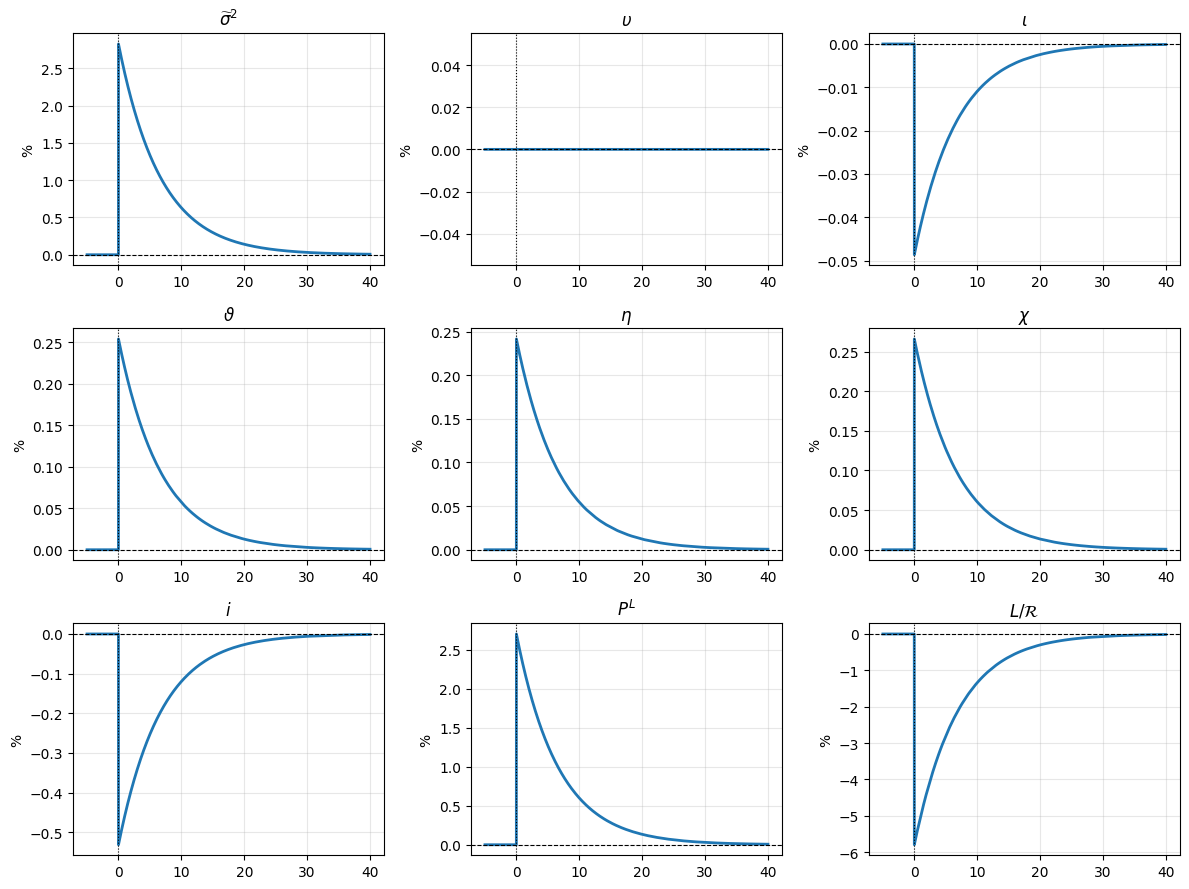

In [10]:
model = get_model(
    NEW_MODEL_PATH,
    model_size=[64, 64, 64, 64],
    batch_size=500,
    num_epochs=500,
    lr=1e-5,
    warm_start=True,
    warm_start_base_model_path=BASE_MODEL_PATH,
)
report_loadings(model, "(optimal policy)")

irf_opt = simulate_irf(model, shock=dZ, horizon=T_irf, dt=dt_irf, pre_shock=ap)
plot_irf(irf_opt, NEW_MODEL_PATH)

optimal_policy = extract_policy(model)
save_policy(optimal_policy, os.path.join(NEW_MODEL_PATH, "policy_optimal.npz"))


## 2. Perturbed marginal-interest-rate policy
`run_perturbed(C)` builds $i^m = i^m_{ss} + C\,(i^{m,opt} - i^m_{ss})$, re-solves the fixed-policy
equilibrium (exact inner block, warm-started from the optimal solution, gentle training),
prints the steady state / loadings, and overlays the integrated IRF on the optimal-policy IRF.
The $C=1$ stage is the correctness check: it must reproduce the optimal response functions.


In [11]:
IRF_PANELS = [("sig2", r"$\widetilde{\sigma}^2$"), ("u", r"$\upsilon$"), ("iota", r"$\iota$"),
              ("v", r"$\vartheta$"), ("eta", r"$\eta$"), ("chi", r"$\chi$"),
              ("i", r"$i$"), ("PL", r"$P^L$"), ("psi", r"$L/\mathcal{R}$")]


def overlay_irfs(results, labels, title):
    fig, axes = plt.subplots(3, 3, figsize=(12, 9))
    for axis, (name, ttl) in zip(axes.ravel(), IRF_PANELS):
        for r, lab in zip(results, labels):
            axis.plot(r["time"], r["responses"][name], linewidth=2, label=lab)
        axis.axhline(0, color="black", linestyle="--", linewidth=0.8)
        axis.axvline(0, color="black", linestyle=":", linewidth=0.8)
        axis.set_title(ttl); axis.set_ylabel("%"); axis.grid(alpha=0.3)
    axes.ravel()[0].legend()
    fig.suptitle(title); fig.tight_layout(); plt.show()


def impact_table(irf_a, irf_b, label_a, label_b):
    ia, ib = int(round(ap / dt_irf)), int(round(ap / 0.05))
    print(f"impact responses      {label_a:>10s} {label_b:>10s}   diff")
    for name, _ in IRF_PANELS:
        a, b = irf_a["responses"][name][ia], irf_b["responses"][name][ib]
        print(f"  {name:6s}          {a:10.4f} {b:10.4f}   {b - a:+.4f}")


def run_perturbed(C, num_epochs=1000, lr=1e-5, widen_factor=2.0):
    policy = perturb_policy(optimal_policy, C, names=("iT",))
    path = f"{PERTURBED_MODEL_PATH}_C{C}"
    m = get_model(
        path,
        model_size=[64, 64, 64, 64],
        batch_size=500,
        num_epochs=num_epochs,
        lr=lr,
        warm_start=True,
        warm_start_base_model_path=NEW_MODEL_PATH,
        policy_table=policy,
        eta_range=widen(efficient_domain(MODEL_PARAMS)[2:4], widen_factor, lo_limit=1e-2, hi_limit=1 - 1e-2),
        u_range=widen(u_domain(MODEL_PARAMS), widen_factor, lo_limit=1e-2),
    )
    report_loadings(m, f"(C = {C})")
    irf = simulate_irf_perturbed(m, shock=dZ, horizon=T_irf, dt=0.05, pre_shock=ap)
    impact_table(irf_opt, irf, "optimal", f"C={C}")
    overlay_irfs([irf_opt, irf], ["optimal", f"C={C}"], f"Impulse responses: optimal vs C = {C}")
    return m, policy, irf


### 2a. $C = 1.0$ — must match the optimal response functions


trained 1000 epochs -> ./models/full_eff_closed_perturbed_2026-09-14T08_02_59_C1.0  (log: model-1000-log.txt)
--- loadings (C = 1.0) ---
  steady state: eta=0.38408 (efficient 0.38334)  u=1.00078 (efficient 1.00000)  |MU|,|MUu|=5.3e-08,1.3e-08
  S_ss=0.002667 (efficient 0.002454)  sig_ups_ss=+0.001744 (efficient 0)  sig_eta=0.00694 (efficient 0.00640)
  chi=0.8450  nu=0.9244  PL=1.0016  pie=+3.94e-05  max|F1..F4|=1.5e-08
steady state: sig2=0.500000, eta=0.384079, u=1.000776
  drift residuals: MU=-5.288e-08, MUu=1.258e-08
  lambda[0] = -0.624857 +0.000000j
  lambda[1] = -0.198780 +0.000000j
  lambda[2] = -0.150204 +0.000000j
  0 unstable root(s)
impact responses         optimal      C=1.0   diff
  sig2                2.8284     2.8284   -0.0000
  u                   0.0000     0.1743   +0.1743
  iota               -0.0486    -0.0448   +0.0038
  v                   0.2541     0.3294   +0.0753
  eta                 0.2415     0.2667   +0.0252
  chi                 0.2660     0.3495   +0.0

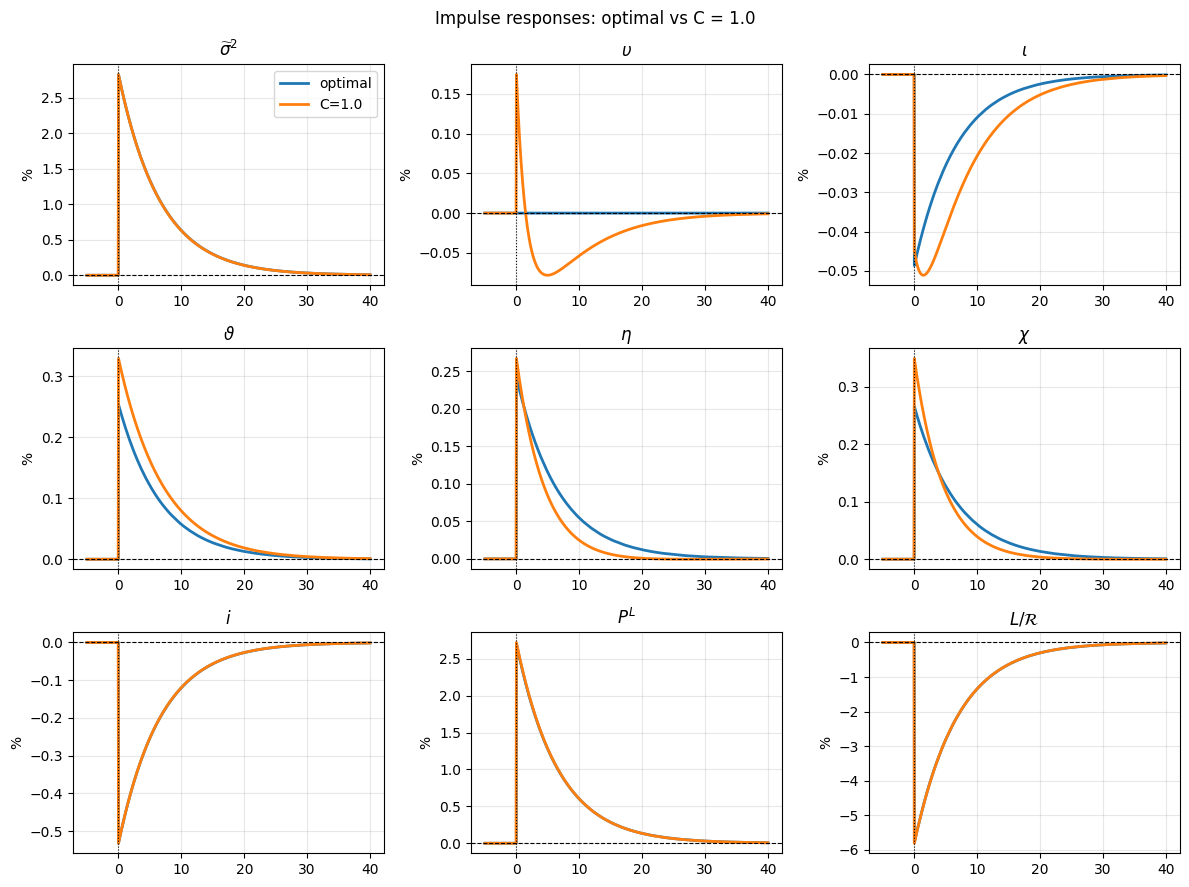

In [12]:
model_c1, policy_c1, irf_c1 = run_perturbed(1.0)


### 2b. $C = 1.1$ — a 10% more aggressive interest-rate policy


trained 1000 epochs -> ./models/full_eff_closed_perturbed_2026-09-14T08_02_59_C1.1  (log: model-1000-log.txt)
--- loadings (C = 1.1) ---
  steady state: eta=0.38372 (efficient 0.38334)  u=1.00013 (efficient 1.00000)  |MU|,|MUu|=2.3e-08,7.1e-08
  S_ss=0.002926 (efficient 0.002454)  sig_ups_ss=+0.005574 (efficient 0)  sig_eta=0.00762 (efficient 0.00640)
  chi=0.8449  nu=0.9541  PL=1.0011  pie=+1.98e-04  max|F1..F4|=6.0e-08
steady state: sig2=0.500000, eta=0.383721, u=1.000127
  drift residuals: MU=-2.273e-08, MUu=7.070e-08
  lambda[0] = -0.626079 +0.000000j
  lambda[1] = -0.201064 +0.000000j
  lambda[2] = -0.150204 +0.000000j
  0 unstable root(s)
impact responses         optimal      C=1.1   diff
  sig2                2.8284     2.8284   -0.0000
  u                   0.0000     0.5574   +0.5574
  iota               -0.0486    -0.0007   +0.0480
  v                   0.2541     0.3072   +0.0531
  eta                 0.2415     0.2926   +0.0511
  chi                 0.2660     0.3656   +0.0

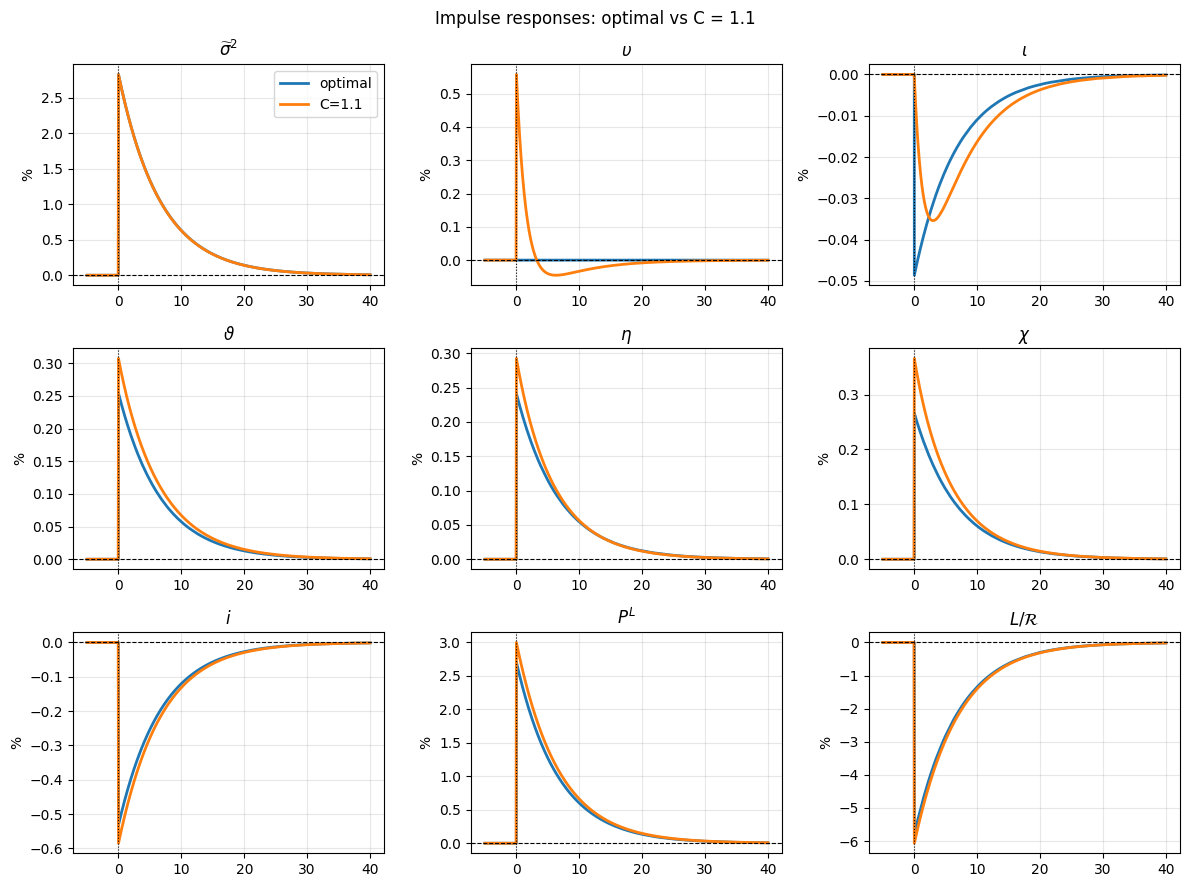

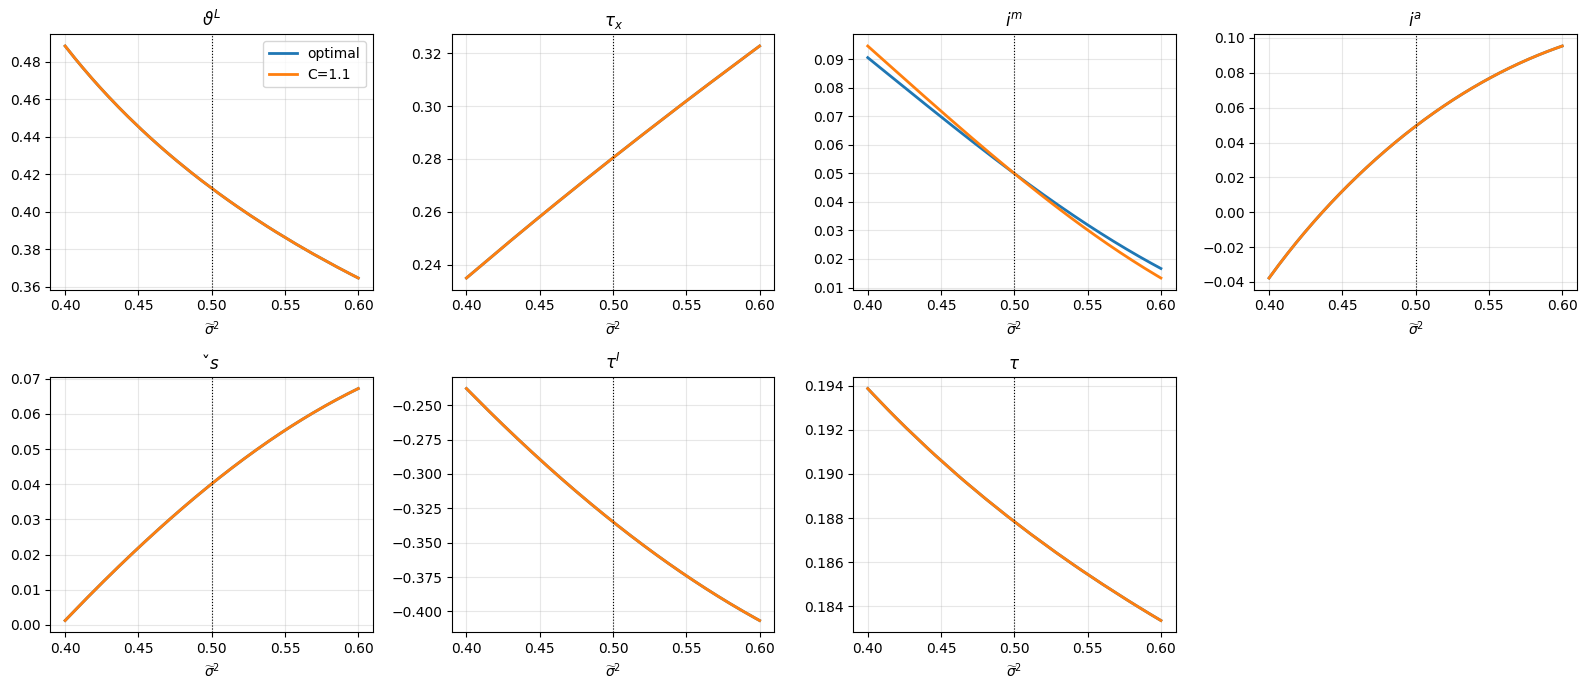

In [13]:
model_c11, policy_c11, irf_c11 = run_perturbed(1.1)
plot_policy([optimal_policy, policy_c11], ["optimal", "C=1.1"], f"{PERTURBED_MODEL_PATH}_C1.1")
